In [1]:
# Import pandas, numpy, sklearn, matplotlib, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample
from scipy.spatial.distance import mahalanobis

# Import Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
convabuse = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/convabuse_cleaned1.csv")
dynamically_generated_hate_speech = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_cleaned1.csv")
online_abusive_attacks = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_cleaned1.csv")
us_elections_2020_hate_speech = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_cleaned1.csv")
mlma_hate_speech = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_cleaned1.csv")

In [3]:
def calc_mahalanobis(data):
  # Only select numerical features
  numeric_data = data.select_dtypes(include="number")
  # Drop columns with zero variance
  numeric_data = numeric_data.loc[:, numeric_data.var() != 0]
  mean_vector = np.mean(numeric_data, axis=0)
  covariance_matrix = np.cov(numeric_data, rowvar=False)
  # Add a small value to the diagonal for regularization
  reg_covariance_matrix = covariance_matrix + np.eye(covariance_matrix.shape[0]) * 1e-6
  inv_covariance_matrix = np.linalg.inv(reg_covariance_matrix)
  mahalanobis_distances = []
  for i in range(len(numeric_data)):
    distance = mahalanobis(numeric_data.iloc[i], mean_vector, inv_covariance_matrix)
    mahalanobis_distances.append(distance)
  sns.histplot(mahalanobis_distances, kde=True)
  plt.title('Distribution of Mahalanobis Distances')
  plt.xlabel('Mahalanobis Distance')
  plt.ylabel('Frequency')
  plt.show()
  return mahalanobis_distances

In [4]:
# Choose corresponding indices in convabuse associated with a mahalanobis distance of 10 or above
def get_inliers(data, mahalanobis_distances, threshold):
  inlier_indices = np.where(np.array(mahalanobis_distances) < threshold)[0]
  inliers = data.iloc[inlier_indices]
  print(f"{len(inliers)} total entries after outlier removal vs {len(data)} total entries before outlier removal.")

  sns.histplot(mahalanobis_distances, kde=True)
  plt.title('Distribution of Mahalanobis Distances')
  plt.xlabel('Mahalanobis Distance')
  plt.ylabel('Frequency')
  plt.show()

  inlier_mahalanobis_distances = [mahalanobis_distances[i] for i in inlier_indices]
  sns.histplot(inlier_mahalanobis_distances, kde=True)
  plt.title('Distribution of Inlier Mahalanobis Distances')
  plt.xlabel('Mahalanobis Distance')
  plt.ylabel('Frequency')
  plt.show()
  return inliers

# Convabuse Dataset

In [5]:
# Preview convabuse
convabuse.head()

,example_no,annotator_id,bot,Not Abusive,Ambiguous,Abusive,Very Abusive,Very Strongly Abusive,ableism,homophobic,intellectual,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit
0,0,7,E.L.I.Z.A.,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,7,E.L.I.Z.A.,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,7,E.L.I.Z.A.,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,7,CarbonBot,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,7,E.L.I.Z.A.,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Create an "abuse_level" column with default values of 0
convabuse['abuse_level'] = 0

In [7]:
convabuse.head()

,example_no,annotator_id,bot,Not Abusive,Ambiguous,Abusive,Very Abusive,Very Strongly Abusive,ableism,homophobic,...,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit,abuse_level
0,0,7,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,7,E.L.I.Z.A.,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,7,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,7,CarbonBot,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,7,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Reassign the abuse_level column
not_abusive = convabuse[convabuse['Not Abusive'] == 1]
not_abusive['abuse_level'] = 0
ambiguous = convabuse[convabuse['Ambiguous'] == 1]
ambiguous['abuse_level'] = 1
abusive = convabuse[convabuse['Abusive'] == 1]
abusive['abuse_level'] = 2
very_abusive = convabuse[convabuse['Very Abusive'] == 1]
very_abusive['abuse_level'] = 3
very_strongly_abusive = convabuse[convabuse['Very Strongly Abusive'] == 1]
very_strongly_abusive['abuse_level'] = 4

# Merge all rows and sort by example_no
convabuse = pd.concat([not_abusive, ambiguous, abusive, very_abusive, very_strongly_abusive])
convabuse = convabuse.sort_values(by='example_no')

/tmp/ipython-input-2803096735.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  not_abusive['abuse_level'] = 0
/tmp/ipython-input-2803096735.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ambiguous['abuse_level'] = 1
/tmp/ipython-input-2803096735.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

In [9]:
convabuse.tail(20)

,example_no,annotator_id,bot,Not Abusive,Ambiguous,Abusive,Very Abusive,Very Strongly Abusive,ableism,homophobic,...,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit,abuse_level
12748,12748,7,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12749,12749,4,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12750,12750,4,E.L.I.Z.A.,0,0,0,0,1,0,0,...,0,1,1,0,0,0,1,1,0,4
12751,12751,4,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12752,12752,7,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12753,12753,4,CarbonBot,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12754,12754,4,CarbonBot,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12755,12755,7,E.L.I.Z.A.,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12756,12756,5,E.L.I.Z.A.,0,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,1,3
12757,12757,4,E.L.I.Z.A.,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,1,0,3


In [10]:
# Drop the abuse level columns as they are no longer needed
convabuse = convabuse.drop(columns=['Not Abusive', 'Ambiguous', 'Abusive', 'Very Abusive', 'Very Strongly Abusive'])
convabuse.head()

,example_no,annotator_id,bot,ableism,homophobic,intellectual,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit,abuse_level
0,0,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,1
2,2,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,7,CarbonBot,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
convabuse["abuse_level"].value_counts()

,count
abuse_level,
0,10068
3,934
2,813
1,671
4,282


In [12]:
# Rename racism to race_or_ethnicity
convabuse = convabuse.rename(columns={'racist': 'race_or_ethnicity'})

# If 1 in either homophobic or transphobic, assign 1 to lgbtq, otherwise, assign 0 to lgbtq
convabuse['lgbtq'] = np.where((convabuse['homophobic'] == 1) | (convabuse['transphobic'] == 1), 1, 0)

# If 1 in either sexist or sex_harassment, assign 1 to gender, otherwise, assign 0 to gender
convabuse['gender'] = np.where((convabuse['sexist'] == 1) | (convabuse['sex_harassment'] == 1), 1, 0)

# If 1 in either  ableism or intellectual, assign 1 to disability, otherwise, assign 0 to disability
convabuse['disability'] = np.where((convabuse['ableism'] == 1) | (convabuse['intellectual'] == 1), 1, 0)

# Remove the other redundant columns
convabuse = convabuse.drop(columns=['sexist', 'transphobic', 'sexist', 'sex_harassment', 'ableism', 'intellectual'])

# Assign 0 columns for religion, nationality, age, class, and none
convabuse['religion'] = 0
convabuse['nationality'] = 0
convabuse['age'] = 0
convabuse['class'] = 0
convabuse['none'] = 0

In [13]:
# Drop example_no and annotator_id
convabuse = convabuse.drop(columns=["example_no"])
convabuse.head()

,annotator_id,bot,homophobic,race_or_ethnicity,generalised,individual,system,explicit,implicit,abuse_level,lgbtq,gender,disability,religion,nationality,age,class,none
0,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,7,E.L.I.Z.A.,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,7,CarbonBot,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,7,E.L.I.Z.A.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
# Change "E.L.I.Z.A." to 0 and "CarbonBot" to 1
convabuse["bot"] = np.where(convabuse['bot'] == "CarbonBot", 1, 0)


In [15]:
convabuse["bot"].value_counts()

,count
bot,
0,8118
1,4650


In [16]:
# Combine race_or_ethnicity, gender, religion, lgbtq, nationality, age, disability, and class into a single column
  # Start with 0 and add 1 for the presence of each characteristic per observation
convabuse["target_groups"] = 0

# Use a for loop to add 1 for each 1 in any of the characteristics
for index, row in convabuse.iterrows():
  convabuse.loc[index, "target_groups"] = row["race_or_ethnicity"] + row["gender"] + row["religion"] + row["lgbtq"] + row["nationality"] + row["age"] + row["disability"] + row["class"]

In [17]:
# Drop the aforementioned columns and none as they are no longer needed
convabuse = convabuse.drop(columns=["homophobic", "race_or_ethnicity", "religion", "gender", "lgbtq", "nationality", "age", "disability", "class", "none"])
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


## Convabuse Outlier Detection

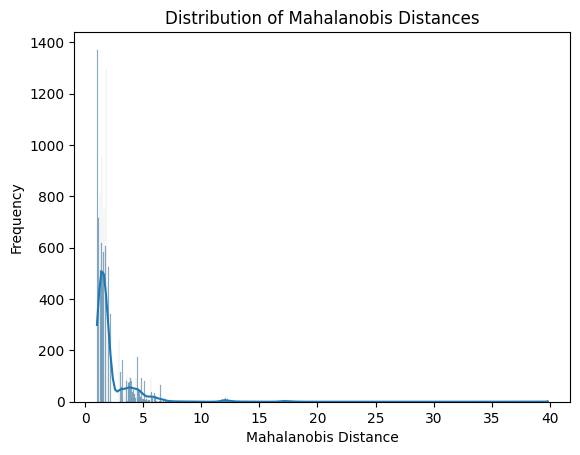

In [18]:
convabuse_mahalanobis_distances = calc_mahalanobis(convabuse)

12577 total entries after outlier removal vs 12768 total entries before outlier removal.


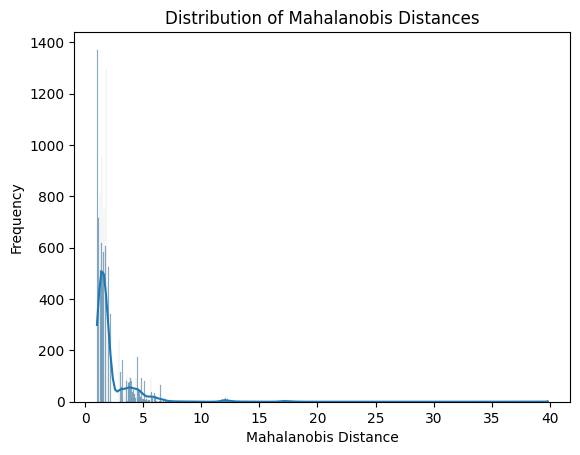

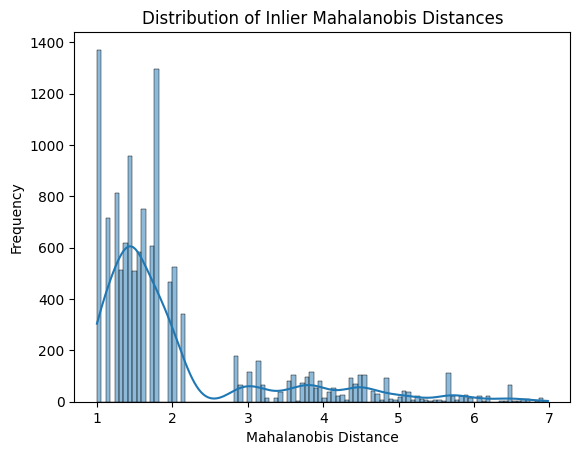

In [19]:
convabuse_inliers = get_inliers(convabuse, convabuse_mahalanobis_distances, 7)

## Convabuse Rebalanced

In [20]:
convabuse_imbalanced = convabuse_inliers

In [21]:
convabuse_imbalanced["abuse_level"].value_counts()

,count
abuse_level,
0,10063
3,867
2,749
1,658
4,240


In [22]:
convabuse_imbalanced.describe()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
count,12577.000000,12577.000000,12577.0,12577.0,12577.000000,12577.000000,12577.000000,12577.00000,12577.000000
mean,4.682595,0.366304,0.0,0.0,0.148048,0.118709,0.029339,0.45456,0.082850
std,2.194301,0.481813,0.0,0.0,0.355162,0.323458,0.168762,1.00485,0.275666
min,1.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
50%,5.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
75%,7.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
max,8.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,4.00000,1.000000


In [23]:
convabuse_imbalanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12577 entries, 0 to 12767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   annotator_id   12577 non-null  int64
 1   bot            12577 non-null  int64
 2   generalised    12577 non-null  int64
 3   individual     12577 non-null  int64
 4   system         12577 non-null  int64
 5   explicit       12577 non-null  int64
 6   implicit       12577 non-null  int64
 7   abuse_level    12577 non-null  int64
 8   target_groups  12577 non-null  int64
dtypes: int64(9)
memory usage: 982.6 KB


In [ ]:
# Resample 0 as the majority class and 1, 2, 3, and 4 as the minority classes in the abuse_level column
convabuse_majority_y = convabuse_imbalanced[convabuse_imbalanced["abuse_level"] == 0]
convabuse_minority_y1 = convabuse_imbalanced[convabuse_imbalanced["abuse_level"] == 1]
convabuse_minority_y2 = convabuse_imbalanced[convabuse_imbalanced["abuse_level"] == 2]
convabuse_minority_y3 = convabuse_imbalanced[convabuse_imbalanced["abuse_level"] == 3]
convabuse_minority_y4 = convabuse_imbalanced[convabuse_imbalanced["abuse_level"] == 4]

# Upsample the minority classes
convabuse_majority_y_downsampled = resample(convabuse_majority_y, random_state=42, n_samples=int(len(convabuse_majority_y) / 2),replace=True)
convabuse_minority_y1_upsampled = resample(convabuse_minority_y1,random_state=42,n_samples=int(len(convabuse_majority_y) / 2),replace=True)
convabuse_minority_y2_upsampled = resample(convabuse_minority_y2,random_state=42,n_samples=int(len(convabuse_majority_y) / 2),replace=True)
convabuse_minority_y3_upsampled = resample(convabuse_minority_y3,random_state=42,n_samples=int(len(convabuse_majority_y) / 2),replace=True)
convabuse_minority_y4_upsampled = resample(convabuse_minority_y4,random_state=42,n_samples=int(len(convabuse_majority_y) / 2),replace=True)

In [ ]:
#concatenate the upsampled dataframe
convabuse_upsampled = pd.concat([convabuse_majority_y_downsampled, convabuse_minority_y1_upsampled, convabuse_minority_y2_upsampled, convabuse_minority_y3_upsampled, convabuse_minority_y4_upsampled]).reset_index()
convabuse_upsampled

,index,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,9239,2,1,0,0,0,0,0,0,0
1,986,7,1,0,0,0,0,0,0,0
2,6901,5,0,0,0,0,0,0,0,0
3,6547,5,0,0,0,0,0,0,0,0
4,7389,3,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
25150,2729,8,0,0,0,1,1,0,4,0
25151,3529,8,0,0,0,1,1,0,4,0
25152,4568,6,0,0,0,1,1,0,4,1
25153,2722,8,1,0,0,1,1,0,4,1


In [ ]:
convabuse_upsampled["abuse_level"].value_counts()

,count
abuse_level,
0,5031
1,5031
2,5031
3,5031
4,5031


In [ ]:
convabuse_upsampled = convabuse_upsampled.drop(columns=['index'])

In [ ]:
convabuse_upsampled["abuse_level"].unique()

array([0, 1, 2, 3, 4])

In [ ]:
convabuse_upsampled.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,2,1,0,0,0,0,0,0,0
1,7,1,0,0,0,0,0,0,0
2,5,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0
4,3,1,0,0,0,0,0,0,0


In [ ]:
convabuse_upsampled.shape

(25155, 9)

In [ ]:
convabuse = convabuse_upsampled

In [ ]:
# Output the convabuse dataframe as a csv file
convabuse.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/convabuse_final.csv", index=False)
convabuse_imbalanced.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/convabuse_imbalanced.csv", index=False)

# Dynamically Generated Hate Speech Dataset

In [24]:
# Preview dynamically_generated_hate_speech
dynamically_generated_hate_speech.head()

,label,type,level,annotator,race_or_ethnicity,gender,religion,lgbtq,nationality,age,disability,class,none
0,1.0,0,original,3,0,0,0,0,0,0,0,0,1
1,1.0,0,original,3,0,0,0,0,0,0,0,0,1
2,1.0,0,original,18,0,0,0,0,0,0,0,0,1
3,1.0,0,original,16,0,0,0,0,0,0,0,0,1
4,1.0,0,original,7,0,0,0,0,0,0,0,0,1


In [25]:
dynamically_generated_hate_speech["type"].value_counts()

,count
type,
0,26079
-1,14858
1,89


In [26]:
dynamically_generated_hate_speech["label"].value_counts()

,count
label,
1.0,22057
0.0,18969


In [27]:
# Combine race_or_ethnicity, gender, religion, lgbtq, nationality, age, disability, and class into a single column
  # Start with 0 and add 1 for the presence of each characteristic per observation
dynamically_generated_hate_speech["target_groups"] = 0

# Use a for loop to add 1 for each 1 in any of the characteristics
for index, row in dynamically_generated_hate_speech.iterrows():
  dynamically_generated_hate_speech.loc[index, "target_groups"] = row["race_or_ethnicity"] + row["gender"] + row["religion"] + row["lgbtq"] + row["nationality"] + row["age"] + row["disability"] + row["class"]

In [28]:
# Drop the aforementioned columns and none as they are no longer needed
dynamically_generated_hate_speech = dynamically_generated_hate_speech.drop(columns=["race_or_ethnicity", "religion", "gender", "lgbtq", "nationality", "age", "disability", "class", "none"])
dynamically_generated_hate_speech.head()

,label,type,level,annotator,target_groups
0,1.0,0,original,3,0
1,1.0,0,original,3,0
2,1.0,0,original,18,0
3,1.0,0,original,16,0
4,1.0,0,original,7,0


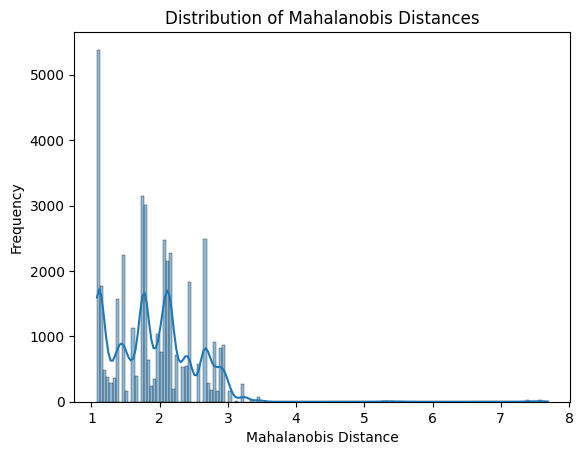

In [29]:
dghs_mahalanobis_distances = calc_mahalanobis(dynamically_generated_hate_speech)

40937 total entries after outlier removal vs 41026 total entries before outlier removal.


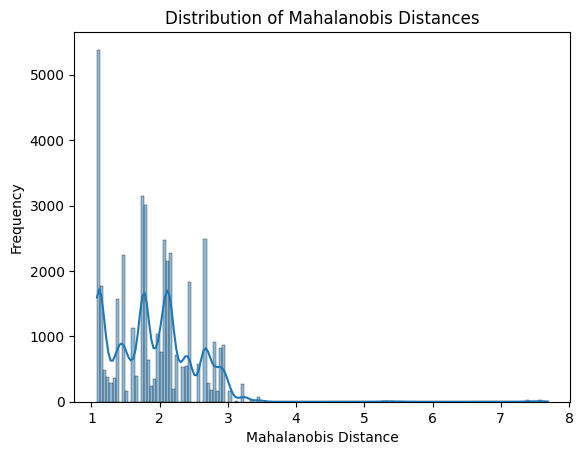

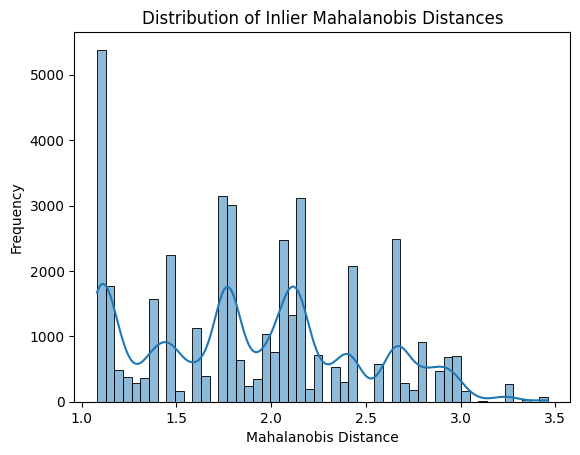

In [30]:
dghs_inliers = get_inliers(dynamically_generated_hate_speech, dghs_mahalanobis_distances, 3.5)

In [31]:
dynamically_generated_hate_speech_imbalanced = dghs_inliers

In [32]:
dghs_inliers["label"].value_counts()

,count
label,
1.0,21968
0.0,18969


In [33]:
# Resample 0 as the majority class and 1 as the minority class in the label column

#set the minority class to a separate dataframe
dynamically_generated_hate_speech_minority_y = dynamically_generated_hate_speech_imbalanced[dynamically_generated_hate_speech_imbalanced['label'] == 1]
#set other classes to another dataframe
dynamically_generated_hate_speech_majority_y = dynamically_generated_hate_speech_imbalanced[dynamically_generated_hate_speech_imbalanced['label'] == 0]
#upsample the minority class
dynamically_generated_hate_speech_minority_y_upsampled = resample(dynamically_generated_hate_speech_minority_y,random_state=42,n_samples=(len(dynamically_generated_hate_speech_majority_y)),replace=True)

In [34]:
#concatenate the upsampled dataframe
dynamically_generated_hate_speech_upsampled = pd.concat([dynamically_generated_hate_speech_minority_y_upsampled, dynamically_generated_hate_speech_majority_y]).reset_index()
dynamically_generated_hate_speech_upsampled

,index,label,type,level,annotator,target_groups
0,30764,1.0,-1,original,4,0
1,1350,1.0,-1,original,9,1
2,10458,1.0,-1,perturbation,16,1
3,40456,1.0,0,original,2,0
4,23310,1.0,-1,original,15,0
...,...,...,...,...,...,...
37933,41000,0.0,0,original,1,0
37934,41016,0.0,0,original,13,0
37935,41020,0.0,0,original,1,0
37936,41023,0.0,0,original,1,0


In [35]:
dynamically_generated_hate_speech_upsampled['label'].value_counts()

,count
label,
1.0,18969
0.0,18969


In [36]:
dynamically_generated_hate_speech_upsampled = dynamically_generated_hate_speech_upsampled.drop(columns=['index'])

In [37]:
dynamically_generated_hate_speech_upsampled.head()

,label,type,level,annotator,target_groups
0,1.0,-1,original,4,0
1,1.0,-1,original,9,1
2,1.0,-1,perturbation,16,1
3,1.0,0,original,2,0
4,1.0,-1,original,15,0


In [38]:
dynamically_generated_hate_speech_upsampled["level"].unique()

array(['original', 'perturbation'], dtype=object)

In [39]:
# Rename level to original, then reassign 1 to "original" values and 0 to "perturbation"
dynamically_generated_hate_speech_upsampled["original"] = dynamically_generated_hate_speech_upsampled["level"]
dynamically_generated_hate_speech_imbalanced["original"] = dynamically_generated_hate_speech_imbalanced["level"]

/tmp/ipython-input-2913297172.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamically_generated_hate_speech_imbalanced["original"] = dynamically_generated_hate_speech_imbalanced["level"]


In [40]:
# Replace "original" with 1 and "perturbation" with 0
dynamically_generated_hate_speech_upsampled["original"] = dynamically_generated_hate_speech_upsampled["original"].replace({"original": 1, "perturbation": 0})
dynamically_generated_hate_speech_imbalanced["original"] = dynamically_generated_hate_speech_imbalanced["original"].replace({"original": 1, "perturbation": 0})

/tmp/ipython-input-155411668.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dynamically_generated_hate_speech_upsampled["original"] = dynamically_generated_hate_speech_upsampled["original"].replace({"original": 1, "perturbation": 0})
/tmp/ipython-input-155411668.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dynamically_generated_hate_speech_imbalanced["original"] = dynamically_generated_hate_speech_imbalanced["original"].replace({"original": 1, "perturbation": 0})
/tmp/ipython-input-155411668.py:3: SettingWithCopyWarnin

In [41]:
dynamically_generated_hate_speech_upsampled["original"].unique()

array([1, 0])

In [42]:
# Drop the level column
dynamically_generated_hate_speech_upsampled = dynamically_generated_hate_speech_upsampled.drop(columns=['level'])
dynamically_generated_hate_speech_imbalanced = dynamically_generated_hate_speech_imbalanced.drop(columns=['level'])

In [43]:
dynamically_generated_hate_speech_imbalanced.describe()

,label,type,annotator,target_groups,original
count,40937.000000,40937.000000,40937.000000,40937.000000,40937.000000
mean,0.536629,-0.362948,7.992916,0.244034,0.635244
std,0.498663,0.480856,5.400231,0.429518,0.481367
min,0.000000,-1.000000,1.000000,0.000000,0.000000
25%,0.000000,-1.000000,3.000000,0.000000,0.000000
50%,1.000000,0.000000,7.000000,0.000000,1.000000
75%,1.000000,0.000000,12.000000,0.000000,1.000000
max,1.000000,0.000000,20.000000,1.000000,1.000000


In [44]:
dynamically_generated_hate_speech_imbalanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40937 entries, 0 to 41025
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   label          40937 non-null  float64
 1   type           40937 non-null  int64  
 2   annotator      40937 non-null  int64  
 3   target_groups  40937 non-null  int64  
 4   original       40937 non-null  int64  
dtypes: float64(1), int64(4)
memory usage: 1.9 MB


In [ ]:
dynamically_generated_hate_speech_upsampled.head()

,label,type,annotator,target_groups,original
0,1.0,-1,4,0,1
1,1.0,-1,9,1,1
2,1.0,-1,16,1,0
3,1.0,0,2,0,1
4,1.0,-1,15,0,1


In [ ]:
dynamically_generated_hate_speech = dynamically_generated_hate_speech_upsampled

In [ ]:
dynamically_generated_hate_speech.shape

(37938, 5)

In [ ]:
# Output dynamically_generated_hate_speech to a csv file
dynamically_generated_hate_speech.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_final.csv", index=False)
dynamically_generated_hate_speech_imbalanced.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_imbalanced.csv", index=False)

# Online Abusive Attacks

In [45]:
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


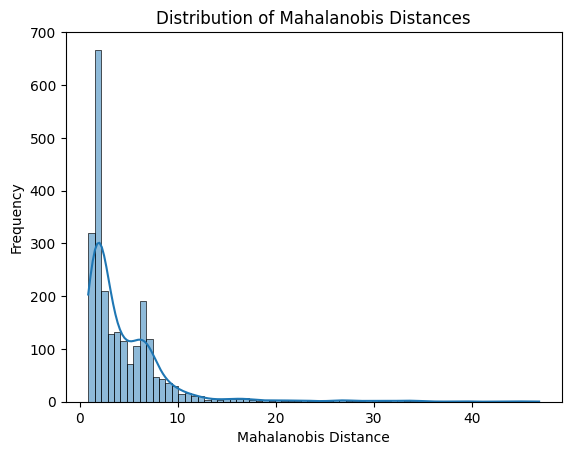

In [46]:
online_abusive_attacks_mahalanobis_distances = calc_mahalanobis(online_abusive_attacks)

2313 total entries after outlier removal vs 2365 total entries before outlier removal.


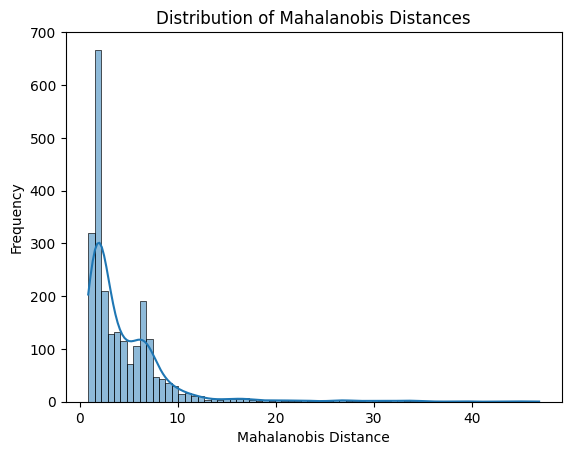

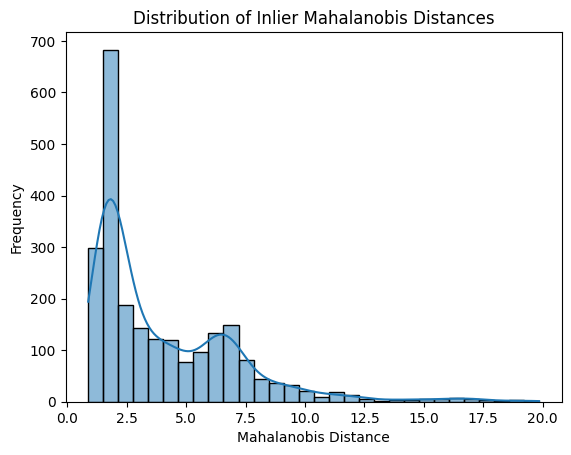

In [47]:
online_abusive_attacks_inliers = get_inliers(online_abusive_attacks, online_abusive_attacks_mahalanobis_distances, 20)

In [48]:
# Summary the Toxicity column in the inliers
online_abusive_attacks_inliers["Toxicity"].describe()

,Toxicity
count,2313.000000
mean,23.029831
std,59.154777
min,0.000000
25%,0.000000
50%,1.000000
75%,16.000000
max,804.000000


In [49]:
online_abusive_attacks_inliers.describe()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
count,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,...,2313.000000,2313.00000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000,2313.000000
mean,1556.190229,297.783831,0.342275,36.459144,2.244995,18.075227,1538.115002,4.954604,292.829226,4.695633,...,0.034155,0.02767,0.029399,0.031128,0.025508,0.025076,0.025508,0.024211,0.025076,23.029831
std,1154.394858,1865.297477,1.771895,96.324815,5.622109,50.021159,1152.558536,29.072531,1843.368263,28.577747,...,0.181666,0.16406,0.168959,0.173702,0.157696,0.156389,0.157696,0.153737,0.156389,59.154777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,530.000000,0.000000,0.000000,0.000000,0.000000,0.000000,518.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1328.000000,2.000000,0.002427,2.000000,1.000000,0.000000,1290.000000,0.000000,2.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2988.000000,61.000000,0.063172,29.000000,1.750000,11.000000,2953.000000,0.000000,60.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000
max,3247.000000,39408.000000,31.246512,1596.000000,79.423729,804.000000,3247.000000,549.000000,39109.000000,549.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,804.000000


In [50]:
online_abusive_attacks_inliers.columns

Index(['Parent tweets', 'Replies to parents', 'Avg replies per parent',
       'Parent tweets with replies', 'Avg replies per parent with replies',
       'Toxic parent tweets', 'Non-toxic parent tweets', 'Toxic replies',
       'Non-toxic replies', 'Toxic replies to non-toxic parents',
       'Non-toxic replies to non-toxic parents',
       'Toxic replies to toxic parents', 'Non-toxic replies to toxic parents',
       'Followers_count', 'Friends_count', 'Listed_count', 'Favourites_count',
       'Verified', 'Statuses_count', 'Retweet_count min', 'Retweet_count avg',
       'Retweet_count max', 'Favorite_count min', 'Favorite_count avg',
       'Favorite_count max', 'Possibly_sensitive',
       'Repliers with min 1 toxic reply', 'High toxicity parents',
       'High severe_toxicity parents', 'High identity_attack parents',
       'High insult parents', 'High profanity parents', 'High threat parents',
       'High other attr parents', 'High toxicity replies',
       'High severe_toxicit

In [51]:
online_abusive_attacks_inliers.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


In [52]:
online_abusive_attacks_inliers.shape

(2313, 55)

In [53]:
online_abusive_attacks_inliers_reduced = online_abusive_attacks_inliers[["Toxic parent tweets", "Toxic replies", "Toxicity"]]
online_abusive_attacks_inliers_reduced.head()

,Toxic parent tweets,Toxic replies,Toxicity
0,0.0,0.0,0.0
1,67.0,13.0,80.0
2,28.0,45.0,73.0
3,47.0,49.0,96.0
4,97.0,7.0,104.0


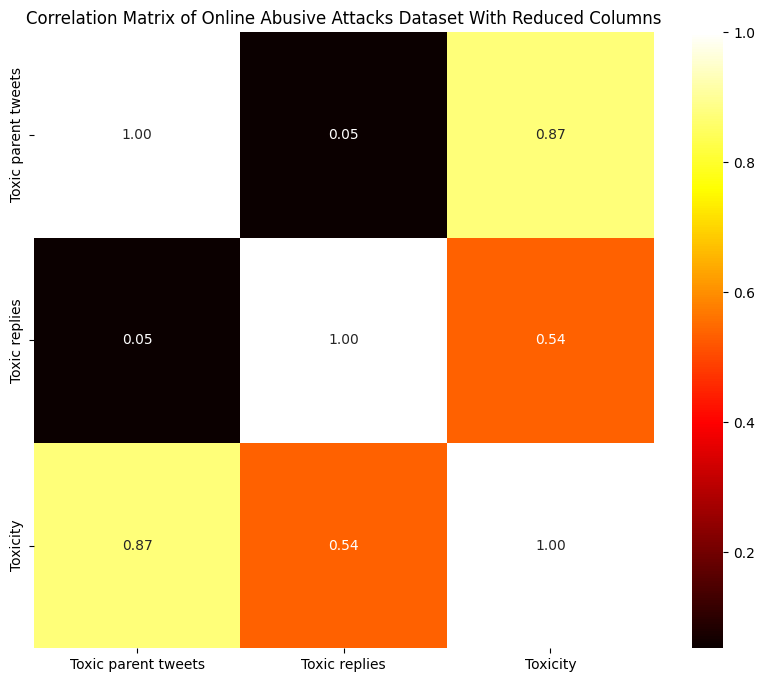

In [54]:
# Correlation matrix of online abusive attacks inliers reduced
plt.figure(figsize=(10, 8))
sns.heatmap(online_abusive_attacks_inliers_reduced.corr(), annot=True, cmap='hot', fmt=".2f")
plt.title('Correlation Matrix of Online Abusive Attacks Dataset With Reduced Columns')
plt.show()

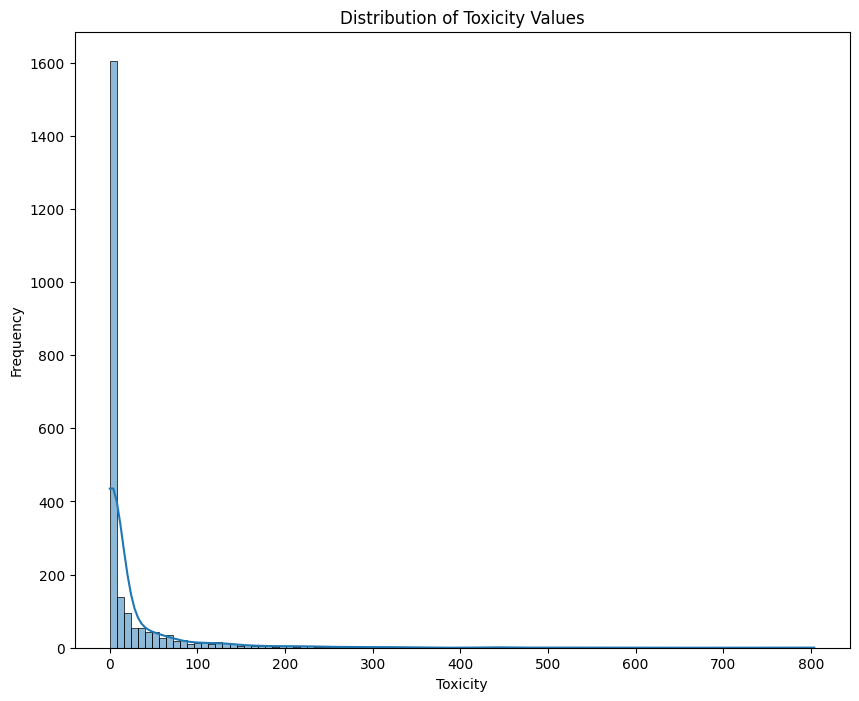

In [55]:
# Get the distribution of values for Toxicity
online_abusive_attacks_inliers_reduced["Toxicity"].value_counts()

# Plot the distribution
plt.figure(figsize=(10, 8))
sns.histplot(online_abusive_attacks_inliers_reduced["Toxicity"], kde=True, bins=100)
plt.title('Distribution of Toxicity Values')
plt.xlabel('Toxicity')
plt.ylabel('Frequency')
plt.show()

In [56]:
online_abusive_attacks_inliers_reduced["Toxic Level"] = 0

/tmp/ipython-input-2497593830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  online_abusive_attacks_inliers_reduced["Toxic Level"] = 0


In [57]:
# Create a new "Toxic" column where 0 if "Toxicity" is 0,
# 1 if "Toxicity" above 0 and below 50
# 2 if "Toxicity" at 50 and below 100
# 3 if "Toxicity" at 100 and below 150
# 4 if "Toxicity" at or above 150
for index, row in online_abusive_attacks_inliers_reduced.iterrows():
  if row["Toxicity"] == 0:
    online_abusive_attacks_inliers_reduced.loc[index, "Toxic Level"] = 0
  if row["Toxicity"] > 0 and row["Toxicity"] < 50:
    online_abusive_attacks_inliers_reduced.loc[index, "Toxic Level"] = 1
  if row["Toxicity"] >= 50 and row["Toxicity"] < 100:
    online_abusive_attacks_inliers_reduced.loc[index, "Toxic Level"] = 2
  if row["Toxicity"] >= 100 and row["Toxicity"] < 150:
    online_abusive_attacks_inliers_reduced.loc[index, "Toxic Level"] = 3
  if row["Toxicity"] >= 150:
    online_abusive_attacks_inliers_reduced.loc[index, "Toxic Level"] = 4

In [58]:
online_abusive_attacks_inliers_reduced.head()

,Toxic parent tweets,Toxic replies,Toxicity,Toxic Level
0,0.0,0.0,0.0,0
1,67.0,13.0,80.0,2
2,28.0,45.0,73.0,2
3,47.0,49.0,96.0,2
4,97.0,7.0,104.0,3


In [59]:
# Drop "Toxicity" and "Toxic"
online_abusive_attacks_inliers_reduced = online_abusive_attacks_inliers_reduced.drop(columns=["Toxicity"])
online_abusive_attacks_inliers_reduced.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [60]:
online_abusive_attacks_inliers_reduced["Toxic Level"].value_counts()

,count
Toxic Level,
0,1112
1,885
2,155
4,88
3,73


In [61]:
online_abusive_attacks_inliers_reduced.describe()

,Toxic parent tweets,Toxic replies,Toxic Level
count,2313.000000,2313.000000,2313.000000
mean,18.075227,4.954604,0.763511
std,50.021159,29.072531,0.980264
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,11.000000,0.000000,1.000000
max,804.000000,549.000000,4.000000


In [62]:
online_abusive_attacks_inliers_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2313 entries, 0 to 2364
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Toxic parent tweets  2313 non-null   float64
 1   Toxic replies        2313 non-null   float64
 2   Toxic Level          2313 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 136.8 KB


In [ ]:
online_abusive_attacks_inliers_reduced.shape

(2313, 3)

In [ ]:
online_abusive_attacks_inliers_majority_y = online_abusive_attacks_inliers_reduced[online_abusive_attacks_inliers_reduced['Toxic Level'] == 0]
online_abusive_attacks_inliers_minority_y1 = online_abusive_attacks_inliers_reduced[online_abusive_attacks_inliers_reduced['Toxic Level'] == 1]
online_abusive_attacks_inliers_minority_y2 = online_abusive_attacks_inliers_reduced[online_abusive_attacks_inliers_reduced['Toxic Level'] == 2]
online_abusive_attacks_inliers_minority_y3 = online_abusive_attacks_inliers_reduced[online_abusive_attacks_inliers_reduced['Toxic Level'] == 3]
online_abusive_attacks_inliers_minority_y4 = online_abusive_attacks_inliers_reduced[online_abusive_attacks_inliers_reduced['Toxic Level'] == 4]

# Upsample for the target_groups
online_abusive_attacks_inliers_upsampled_y1 = resample(online_abusive_attacks_inliers_minority_y1,random_state=42,n_samples=len(online_abusive_attacks_inliers_majority_y),replace=True)
online_abusive_attacks_inliers_upsampled_y2 = resample(online_abusive_attacks_inliers_minority_y2,random_state=42,n_samples=len(online_abusive_attacks_inliers_majority_y),replace=True)
online_abusive_attacks_inliers_upsampled_y3 = resample(online_abusive_attacks_inliers_minority_y3,random_state=42,n_samples=len(online_abusive_attacks_inliers_majority_y),replace=True)
online_abusive_attacks_inliers_upsampled_y4 = resample(online_abusive_attacks_inliers_minority_y4,random_state=42,n_samples=len(online_abusive_attacks_inliers_majority_y),replace=True)

#concatenate the upsampled dataframe
online_abusive_attacks_inliers_upsampled = pd.concat([online_abusive_attacks_inliers_majority_y, online_abusive_attacks_inliers_upsampled_y1, online_abusive_attacks_inliers_upsampled_y2, online_abusive_attacks_inliers_upsampled_y3, online_abusive_attacks_inliers_upsampled_y4]).reset_index()
online_abusive_attacks_inliers_upsampled.head()

,index,Toxic parent tweets,Toxic replies,Toxic Level
0,0,0.0,0.0,0
1,5,0.0,0.0,0
2,6,0.0,0.0,0
3,10,0.0,0.0,0
4,11,0.0,0.0,0


In [ ]:
# View the distribution of HOF values
online_abusive_attacks_inliers_upsampled['Toxic Level'].value_counts()

,count
Toxic Level,
0,1112
1,1112
2,1112
3,1112
4,1112


In [ ]:
online_abusive_attacks_inliers_upsampled.shape

(5560, 4)

In [ ]:
# Output online_abusive_attacks_hate_speech to a csv file
online_abusive_attacks_inliers.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_final.csv", index=False)

In [ ]:
online_abusive_attacks_inliers_reduced.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_class_imbalanced.csv", index=False)
online_abusive_attacks_inliers_upsampled.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_class_final.csv", index=False)

# Hate Speech 2020 US Elections Dataset

In [63]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,0.0,4.0,0.0,Non-Hateful
1,0.0,4.0,0.0,Non-Hateful
2,1.0,2.0,0.0,Non-Hateful
3,4.0,2.0,0.0,Non-Hateful
4,2.0,0.0,0.0,Non-Hateful


In [64]:
# For the Trump, Biden, and West columns, change 0.0 to "Favor", 1.0 to "Against", 2.0 to "Neutral", 3.0 to "Neutral", and 4.0 to "Neutral"
us_elections_2020_hate_speech["Trump"] = us_elections_2020_hate_speech["Trump"].replace({0.0: "Favor", 1.0: "Against", 2.0: "Neutral", 3.0: "Neutral", 4.0: "Neutral"})
us_elections_2020_hate_speech["Biden"] = us_elections_2020_hate_speech["Biden"].replace({0.0: "Favor", 1.0: "Against", 2.0: "Neutral", 3.0: "Neutral", 4.0: "Neutral"})
us_elections_2020_hate_speech["West"] = us_elections_2020_hate_speech["West"].replace({0.0: "Favor", 1.0: "Against", 2.0: "Neutral", 3.0: "Neutral", 4.0: "Neutral"})

In [65]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,Favor,Neutral,Favor,Non-Hateful
1,Favor,Neutral,Favor,Non-Hateful
2,Against,Neutral,Favor,Non-Hateful
3,Neutral,Neutral,Favor,Non-Hateful
4,Neutral,Favor,Favor,Non-Hateful


In [66]:
# In the Trump, Biden, and West columns, change "Favor" to integer 1, "Neutral" to integer 0, and "Against" to integer -1
us_elections_2020_hate_speech["Trump"] = us_elections_2020_hate_speech["Trump"].replace({"Favor": 1, "Neutral": 0, "Against": -1})
us_elections_2020_hate_speech["Biden"] = us_elections_2020_hate_speech["Biden"].replace({"Favor": 1, "Neutral": 0, "Against": -1})
us_elections_2020_hate_speech["West"] = us_elections_2020_hate_speech["West"].replace({"Favor": 1, "Neutral": 0, "Against": -1})

/tmp/ipython-input-2756862394.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  us_elections_2020_hate_speech["Trump"] = us_elections_2020_hate_speech["Trump"].replace({"Favor": 1, "Neutral": 0, "Against": -1})
/tmp/ipython-input-2756862394.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  us_elections_2020_hate_speech["Biden"] = us_elections_2020_hate_speech["Biden"].replace({"Favor": 1, "Neutral": 0, "Against": -1})
/tmp/ipython-input-2756862394.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be

In [67]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,Non-Hateful
1,1,0,1,Non-Hateful
2,-1,0,1,Non-Hateful
3,0,0,1,Non-Hateful
4,0,1,1,Non-Hateful


In [68]:
us_elections_2020_hate_speech['HOF'].unique()

array(['Non-Hateful', 'Hateful'], dtype=object)

In [69]:
# Replace values of "Non-Hateful" with 0 and values of "Hateful" with 1
us_elections_2020_hate_speech['HOF'] = us_elections_2020_hate_speech['HOF'].replace({'Non-Hateful': 0, 'Hateful': 1})

/tmp/ipython-input-2594426102.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  us_elections_2020_hate_speech['HOF'] = us_elections_2020_hate_speech['HOF'].replace({'Non-Hateful': 0, 'Hateful': 1})


In [70]:
# View the distribution of HOF values
us_elections_2020_hate_speech['HOF'].value_counts()

,count
HOF,
0,2648
1,352


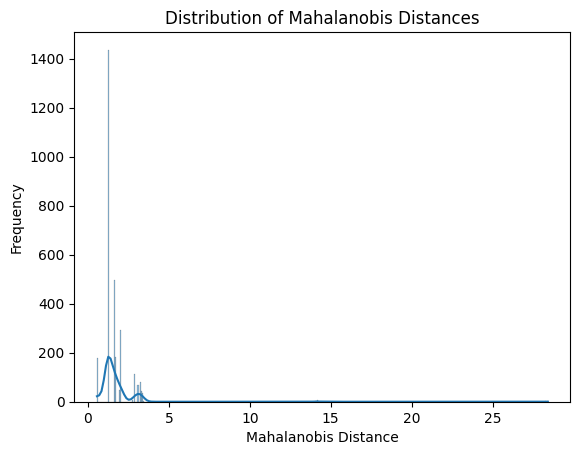

In [71]:
us2020hs_mahalanobis_distances = calc_mahalanobis(us_elections_2020_hate_speech)

2991 total entries after outlier removal vs 3000 total entries before outlier removal.


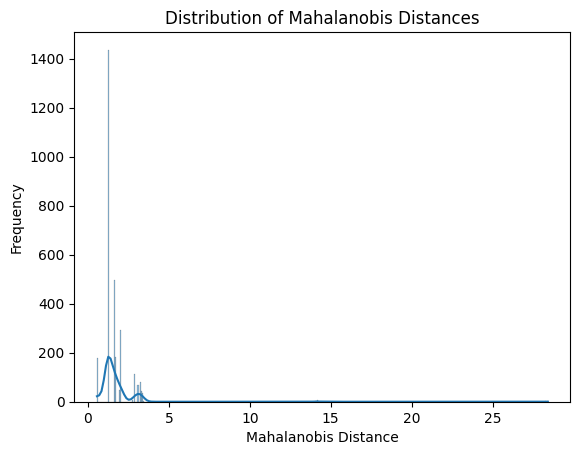

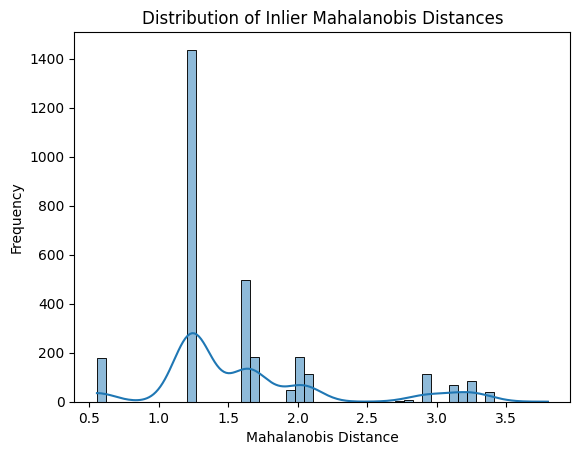

In [72]:
us_elections_inliers = get_inliers(us_elections_2020_hate_speech, us2020hs_mahalanobis_distances, 4)

In [73]:
us_elections_inliers["HOF"].value_counts()

,count
HOF,
0,2639
1,352


In [74]:
us_elections_2020_hate_speech_imbalanced = us_elections_inliers

In [75]:
us_elections_2020_hate_speech_imbalanced.describe()

,Trump,Biden,West,HOF
count,2991.000000,2991.000000,2991.0,2991.000000
mean,0.057172,0.192243,1.0,0.117686
std,0.784725,0.652359,0.0,0.322290
min,-1.000000,-1.000000,1.0,0.000000
25%,-1.000000,0.000000,1.0,0.000000
50%,0.000000,0.000000,1.0,0.000000
75%,1.000000,1.000000,1.0,0.000000
max,1.000000,1.000000,1.0,1.000000


In [76]:
us_elections_2020_hate_speech_imbalanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2991 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Trump   2991 non-null   int64
 1   Biden   2991 non-null   int64
 2   West    2991 non-null   int64
 3   HOF     2991 non-null   int64
dtypes: int64(4)
memory usage: 116.8 KB


In [ ]:
# Resample 0 as the majority class and 1 as the minority class in the HOF column

#set the minority class to a seperate dataframe
us_elections_2020_hate_speech_minority_y = us_elections_2020_hate_speech_imbalanced[us_elections_2020_hate_speech_imbalanced['HOF'] == 1]
#set other classes to another dataframe
us_elections_2020_hate_speech_majority_y = us_elections_2020_hate_speech_imbalanced[us_elections_2020_hate_speech_imbalanced['HOF'] == 0]
#upsample the minority class
us_elections_2020_hate_speech_minority_y_upsampled = resample(us_elections_2020_hate_speech_minority_y,random_state=42,n_samples=(len(us_elections_2020_hate_speech_majority_y)),replace=True)

In [ ]:
#concatenate the upsampled dataframe
us_elections_2020_hate_speech_upsampled = pd.concat([us_elections_2020_hate_speech_minority_y_upsampled, us_elections_2020_hate_speech_majority_y]).reset_index()
us_elections_2020_hate_speech_upsampled

,index,Trump,Biden,West,HOF
0,873,-1,0,1,1
1,2947,1,0,1,1
2,2274,1,0,1,1
3,902,-1,0,1,1
4,554,0,-1,1,1
...,...,...,...,...,...
5273,2995,1,0,1,0
5274,2996,0,-1,1,0
5275,2997,0,1,1,0
5276,2998,-1,0,1,0


In [ ]:
us_elections_2020_hate_speech_upsampled = us_elections_2020_hate_speech_upsampled.drop("index", axis=1)

In [ ]:
us_elections_2020_hate_speech_upsampled['HOF'].value_counts()

,count
HOF,
1,2639
0,2639


In [ ]:
us_elections_2020_hate_speech = us_elections_2020_hate_speech_upsampled

In [ ]:
us_elections_2020_hate_speech.shape

(5278, 4)

In [ ]:
# Output the us_elections_2020_hate_speech dataset
us_elections_2020_hate_speech.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_final.csv", index=False)
us_elections_2020_hate_speech_imbalanced.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_imbalanced.csv", index=False)

# MLMA Hate Speech Dataset

In [77]:
mlma_hate_speech.head()

,HITId,directness,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,race_or_ethnicity,...,age,disability,class,none,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive
0,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
1,2,0,0,1,1,1,1,1,0,0,...,0,0,0,0,1,0,1,0,0,0
2,3,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,4,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
4,5,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [78]:
mlma_hate_speech_changed = mlma_hate_speech.copy()

In [ ]:
# mlma_hate_speech_changed['abuse_level'].unique()

In [ ]:
# # View the distribution of HOF values
# mlma_hate_speech_changed['abuse_level'].value_counts()

In [79]:
# Drop HITId
mlma_hate_speech_changed = mlma_hate_speech_changed.drop(columns=["HITId", "directness"])

In [80]:
# Combine race_or_ethnicity, gender, religion, lgbtq, nationality, age, disability, and class into a single column
  # Start with 0 and add 1 for the presence of each characteristic per observation
mlma_hate_speech_changed["target_groups"] = 0

# Use a for loop to add 1 for each 1 in any of the characteristics
for index, row in mlma_hate_speech_changed.iterrows():
  mlma_hate_speech_changed.loc[index, "target_groups"] = row["race_or_ethnicity"] + row["gender"] + row["religion"] + row["lgbtq"] + row["nationality"] + row["age"] + row["disability"] + row["class"]

In [81]:
# Drop the aforementioned columns and none as they are no longer needed
mlma_hate_speech_changed = mlma_hate_speech_changed.drop(columns=["race_or_ethnicity", "religion", "gender", "lgbtq", "nationality", "age", "disability", "class", "none"])
mlma_hate_speech_changed.head()

,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
0,1,0,0,0,0,0,0,1,0,0,1,1,0,1
1,0,1,1,1,1,1,0,1,0,1,0,0,0,0
2,0,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0,0,0,0,1,0,0,0,1,0,1,0,0,1
4,0,0,0,0,1,0,0,1,0,0,1,0,0,1


In [82]:
# Combine shock, anger, confusion, indifference, sadness, disgust, and fear into a single column
  # Start with 0 and add 1 for the presence of each characteristic per observation
mlma_hate_speech_changed["annotator_sentiment"] = 0

# Use a for loop to add 1 for each 1 in any of the characteristics
for index, row in mlma_hate_speech_changed.iterrows():
  mlma_hate_speech_changed.loc[index, "annotator_sentiment"] = (row["shock_annotator_sentiment"]*2) + (row["anger_annotator_sentiment"]*2) + (row["confusion_annotator_sentiment"]*1) + (row["sadness_annotator_sentiment"]*1) + (row["disgust_annotator_sentiment"]*2) + (row["fear_annotator_sentiment"]*2)

mlma_hate_speech_changed.head()

,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups,annotator_sentiment
0,1,0,0,0,0,0,0,1,0,0,1,1,0,1,2
1,0,1,1,1,1,1,0,1,0,1,0,0,0,0,6
2,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0
4,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0


In [83]:
# Drop the aforementioned columns and none as they are no longer needed
mlma_hate_speech_changed = mlma_hate_speech_changed.drop(columns=["shock_annotator_sentiment", "anger_annotator_sentiment", "confusion_annotator_sentiment", "indifference_annotator_sentiment", "sadness_annotator_sentiment", "disgust_annotator_sentiment", "fear_annotator_sentiment"])
mlma_hate_speech_changed.head()

,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups,annotator_sentiment
0,1,0,0,1,1,0,1,2
1,1,0,1,0,0,0,0,6
2,1,0,1,0,0,0,0,0
3,0,1,0,1,0,0,1,0
4,1,0,0,1,0,0,1,0


In [84]:
# Convert Not Abusive instances of 1 to 0, Very Abusive Instances of 1 to 2, and Very Strongly Abusive instances of 1 to 3
  # Then sum Not Abusive, Abusive, Very Abusive, and Very Strongly Abusive values into a new "abuse_level" column
mlma_hate_speech_changed["abuse_level"] = 0
for index, row in mlma_hate_speech_changed.iterrows():
  # Change Not Abusive
  if row["Not Abusive"] == 1:
    mlma_hate_speech_changed.loc[index, "Not Abusive"] = 0
  if row["Abusive"] == 1:
    mlma_hate_speech_changed.loc[index, "Abusive"] = 1
  if row["Very Abusive"] == 1:
    mlma_hate_speech_changed.loc[index, "Very Abusive"] = 2
  if row["Very Strongly Abusive"] == 1:
    mlma_hate_speech_changed.loc[index, "Very Strongly Abusive"] = 3
  mlma_hate_speech_changed.loc[index, "abuse_level"] = row["Not Abusive"] + row["Abusive"] + row["Very Abusive"] + row["Very Strongly Abusive"]

In [85]:
mlma_hate_speech_changed = mlma_hate_speech_changed.drop(columns=["Not Abusive", "Abusive", "Very Abusive", "Very Strongly Abusive"])
mlma_hate_speech_changed.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


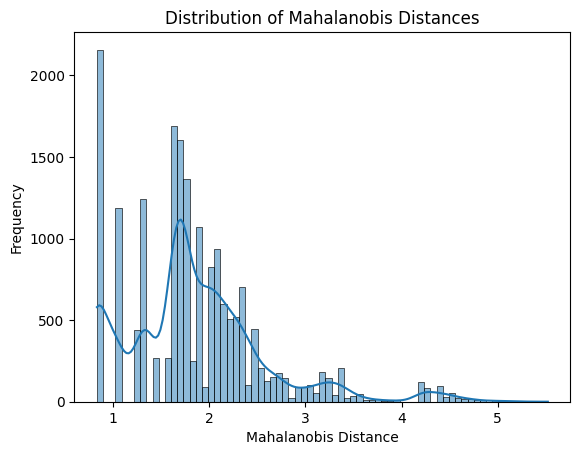

In [86]:
mlma_hate_speech_mahalanobis_distances = calc_mahalanobis(mlma_hate_speech_changed)

18660 total entries after outlier removal vs 18661 total entries before outlier removal.


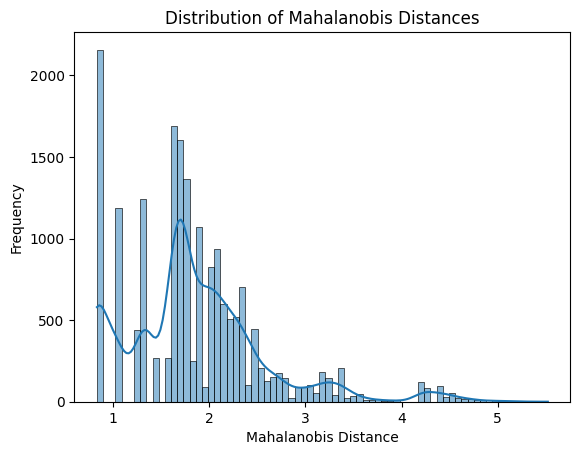

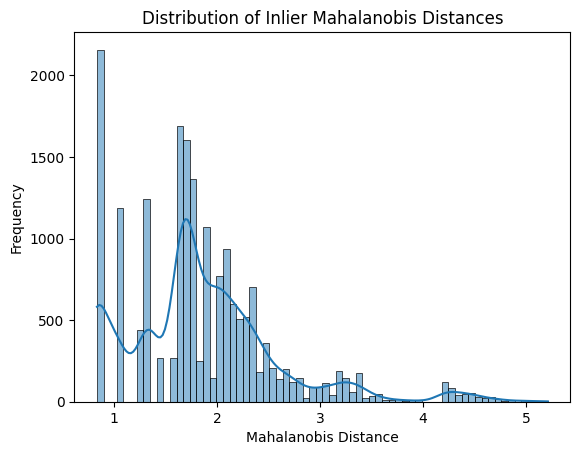

In [87]:
mlma_hate_speech_inliers = get_inliers(mlma_hate_speech_changed, mlma_hate_speech_mahalanobis_distances, 5.5)

In [88]:
# View the distribution of HOF values
mlma_hate_speech_inliers['target_groups'].value_counts()

,count
target_groups,
1,10839
0,4186
2,3145
3,490


In [89]:
mlma_hate_speech_inliers.describe()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
count,18660.000000,18660.000000,18660.000000,18660.000000,18660.000000
mean,0.722347,0.277653,0.996731,3.243140,1.282690
std,0.447853,0.447853,0.705639,2.441138,0.648778
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,0.000000,1.000000,3.000000,1.000000
75%,1.000000,1.000000,1.000000,4.000000,1.000000
max,1.000000,1.000000,3.000000,9.000000,4.000000


In [90]:
mlma_hate_speech_inliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18660 entries, 0 to 18660
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   implicit             18660 non-null  int64
 1   explicit             18660 non-null  int64
 2   target_groups        18660 non-null  int64
 3   annotator_sentiment  18660 non-null  int64
 4   abuse_level          18660 non-null  int64
dtypes: int64(5)
memory usage: 874.7 KB


In [ ]:
# #concatenate the upsampled dataframe
# mlma_hate_speech_inliers

In [ ]:
mlma_hate_speech_inliers_majority_y = mlma_hate_speech_inliers[mlma_hate_speech_inliers['target_groups'] == 1]
mlma_hate_speech_inliers_minority_y1 = mlma_hate_speech_inliers[mlma_hate_speech_inliers['target_groups'] == 0]
mlma_hate_speech_inliers_minority_y2 = mlma_hate_speech_inliers[mlma_hate_speech_inliers['target_groups'] == 2]
mlma_hate_speech_inliers_minority_y3 = mlma_hate_speech_inliers[mlma_hate_speech_inliers['target_groups'] == 3]

# Upsample for the target_groups
mlma_hate_speech_inliers_downsampled_y = resample(mlma_hate_speech_inliers_majority_y,random_state=42,n_samples=int(len(mlma_hate_speech_inliers_majority_y) / 2))
mlma_hate_speech_inliers_upsampled_y1 = resample(mlma_hate_speech_inliers_minority_y1,random_state=42,n_samples=int(len(mlma_hate_speech_inliers_majority_y) / 2),replace=True)
mlma_hate_speech_inliers_upsampled_y2 = resample(mlma_hate_speech_inliers_minority_y2,random_state=42,n_samples=int(len(mlma_hate_speech_inliers_majority_y) / 2),replace=True)
mlma_hate_speech_inliers_upsampled_y3 = resample(mlma_hate_speech_inliers_minority_y3,random_state=42,n_samples=int(len(mlma_hate_speech_inliers_majority_y) / 2),replace=True)

#concatenate the upsampled dataframe
mlma_hate_speech_inliers_upsampled = pd.concat([mlma_hate_speech_inliers_upsampled_y1, mlma_hate_speech_inliers_upsampled_y2, mlma_hate_speech_inliers_upsampled_y3, mlma_hate_speech_inliers_downsampled_y]).reset_index()
mlma_hate_speech_inliers_upsampled

,index,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1861,1,0,0,2,1
1,17955,1,0,0,2,1
2,15485,1,0,0,2,1
3,1015,1,0,0,0,1
4,16627,1,0,0,1,1
...,...,...,...,...,...,...
21671,9920,1,0,1,3,1
21672,9025,1,0,1,1,1
21673,11525,1,0,1,4,1
21674,7716,1,0,1,2,1


In [ ]:
# View the distribution of HOF values
mlma_hate_speech_inliers_upsampled['target_groups'].value_counts()

,count
target_groups,
0,5419
2,5419
3,5419
1,5419


In [ ]:
mlma_hate_speech = mlma_hate_speech_inliers_upsampled

In [ ]:
mlma_hate_speech.head()

,index,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1861,1,0,0,2,1
1,17955,1,0,0,2,1
2,15485,1,0,0,2,1
3,1015,1,0,0,0,1
4,16627,1,0,0,1,1


In [ ]:
mlma_hate_speech.shape

(21676, 6)

In [ ]:
# Output the mlma_hate_speech_upsampled dataset
mlma_hate_speech.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_final.csv", index=False)
mlma_hate_speech_inliers.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_imbalanced.csv", index=False)